# 04 Ablation 2: Encoding Strategy

**Research question**: Does Target Encoding outperform Label Encoding
for categorical features in this multiclass intrusion detection task?

**Design**:
- Model: Random Forest (fixed)
- Class imbalance strategy: best result from Ablation 1 (fixed = SMOTE)
- Variable: encoding strategy (2 conditions)

**Strategies compared**:
1. Label Encoding (baseline)
2. Target Encoding

**Primary metric**: Per-class Recall  
**Secondary metrics**: Macro F1

> **Note on SMOTE cap**: Same bounded `sampling_strategy` as Notebook 03 is applied
> (minority classes capped at `min(2nd-largest-count, 50 000)`) to avoid MemoryError/timeout.

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
import category_encoders as ce

PROJECT_ROOT = Path('..')
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
OUTPUT_DIR = PROJECT_ROOT / 'data' / 'outputs'

RANDOM_STATE = 42

# Best strategy from Ablation 1
BEST_IMBALANCE_STRATEGY = 'SMOTE'

In [2]:
X_train = pd.read_csv(PROCESSED_DIR / 'X_train_baseline.csv')
X_test  = pd.read_csv(PROCESSED_DIR / 'X_test_baseline.csv')
y_train = pd.read_csv(PROCESSED_DIR / 'y_train_baseline.csv').squeeze()
y_test  = pd.read_csv(PROCESSED_DIR / 'y_test_baseline.csv').squeeze()

print('Loaded baseline data')
print('X_train:', X_train.shape)
print('X_test:', X_test.shape)

Loaded baseline data
X_train: (2032037, 43)
X_test: (508010, 43)


In [3]:
# Precompute sampling cap (same as Ablation 1)
class_counts = y_train.value_counts()
majority_class = class_counts.idxmax()
second_largest = int(class_counts.sort_values(ascending=False).iloc[1])
OVERSAMPLE_CAP = min(second_largest, 50000)
print(f'Majority class : {majority_class} ({class_counts[majority_class]:,})')
print(f'Oversample cap : {OVERSAMPLE_CAP:,} per minority class')

def apply_imbalance_strategy(X, y, strategy):
    """Apply the given imbalance strategy with cap to prevent MemoryError."""
    if strategy == 'None':
        return X, y
    elif strategy == 'class_weight':
        return X, y  # handled inside RF directly
    elif strategy == 'RandomOverSampling':
        ros_strat = {
            cls: OVERSAMPLE_CAP
            for cls, cnt in y.value_counts().items()
            if cls != majority_class and cnt < OVERSAMPLE_CAP
        }
        ros = RandomOverSampler(sampling_strategy=ros_strat, random_state=RANDOM_STATE)
        return ros.fit_resample(X, y)
    elif strategy == 'RandomUnderSampling':
        cnts = y.value_counts()
        rus_strat = {
            cls: (second_largest if cls == majority_class else int(cnt))
            for cls, cnt in cnts.items()
        }
        rus = RandomUnderSampler(sampling_strategy=rus_strat, random_state=RANDOM_STATE)
        return rus.fit_resample(X, y)
    elif strategy == 'SMOTE':
        cnts = y.value_counts()
        min_count = cnts.min()
        k = min(5, min_count - 1)
        smote_strat = {
            cls: OVERSAMPLE_CAP
            for cls, cnt in cnts.items()
            if cls != majority_class and cnt < OVERSAMPLE_CAP
        }
        smote = SMOTE(sampling_strategy=smote_strat, random_state=RANDOM_STATE, k_neighbors=k)
        return smote.fit_resample(X, y)
    else:
        raise ValueError(f'Unknown strategy: {strategy}')

class_weight_param = 'balanced' if BEST_IMBALANCE_STRATEGY == 'class_weight' else None

Majority class : Normal (1,775,011)
Oversample cap : 50,000 per minority class


In [4]:
categorical_cols = ['sport', 'dsport', 'proto', 'state', 'service', 'ct_ftp_cmd']

# --- Label Encoding ---
le_dict = {}
X_train_le = X_train.copy()
X_test_le  = X_test.copy()

for col in categorical_cols:
    le = LabelEncoder()
    X_train_le[col] = le.fit_transform(X_train_le[col].astype(str))
    le_classes = set(le.classes_)
    X_test_le[col] = X_test_le[col].astype(str).apply(
        lambda x: x if x in le_classes else le.classes_[0]
    )
    X_test_le[col] = le.transform(X_test_le[col])
    le_dict[col] = le

# Apply best imbalance strategy (capped SMOTE)
X_tr_le, y_tr_le = apply_imbalance_strategy(X_train_le, y_train, BEST_IMBALANCE_STRATEGY)
print(f'After {BEST_IMBALANCE_STRATEGY}: {X_train_le.shape[0]:,} -> {X_tr_le.shape[0]:,} samples')

# Train and evaluate
clf_le = RandomForestClassifier(
    n_estimators=100, random_state=RANDOM_STATE,
    n_jobs=-1, class_weight=class_weight_param
)
clf_le.fit(X_tr_le, y_tr_le)
y_pred_le = clf_le.predict(X_test_le)

report_le = classification_report(y_test, y_pred_le, output_dict=True, zero_division=0)
macro_f1_le = f1_score(y_test, y_pred_le, average='macro', zero_division=0)

print('=== Label Encoding ===')
print(classification_report(y_test, y_pred_le, zero_division=0))

After SMOTE: 2,032,037 -> 2,347,396 samples


=== Label Encoding ===


                precision    recall  f1-score   support

      Analysis       0.09      0.17      0.12       535
      Backdoor       0.05      0.11      0.07       466
           DoS       0.34      0.53      0.41      3271
      Exploits       0.78      0.62      0.69      8905
       Fuzzers       0.67      0.66      0.67      4849
       Generic       1.00      0.99      0.99     43096
        Normal       1.00      1.00      1.00    443753
Reconnaissance       0.89      0.78      0.83      2798
     Shellcode       0.59      0.92      0.72       302
         Worms       0.44      0.60      0.51        35

      accuracy                           0.98    508010
     macro avg       0.58      0.64      0.60    508010
  weighted avg       0.98      0.98      0.98    508010



In [5]:
# --- Target Encoding ---
# Fit on training data only; uses numeric target temporarily
from sklearn.preprocessing import LabelEncoder as LE

le_y = LE()
y_train_num = le_y.fit_transform(y_train)

te = ce.TargetEncoder(cols=categorical_cols, smoothing=1.0)
X_train_te = X_train.copy()
X_test_te  = X_test.copy()

te.fit(X_train_te[categorical_cols], y_train_num)
X_train_te[categorical_cols] = te.transform(X_train_te[categorical_cols])
X_test_te[categorical_cols]  = te.transform(X_test_te[categorical_cols])

# Apply best imbalance strategy (capped SMOTE)
X_tr_te, y_tr_te = apply_imbalance_strategy(X_train_te, y_train, BEST_IMBALANCE_STRATEGY)
print(f'After {BEST_IMBALANCE_STRATEGY}: {X_train_te.shape[0]:,} -> {X_tr_te.shape[0]:,} samples')

# Train and evaluate
clf_te = RandomForestClassifier(
    n_estimators=100, random_state=RANDOM_STATE,
    n_jobs=-1, class_weight=class_weight_param
)
clf_te.fit(X_tr_te, y_tr_te)
y_pred_te = clf_te.predict(X_test_te)

report_te = classification_report(y_test, y_pred_te, output_dict=True, zero_division=0)
macro_f1_te = f1_score(y_test, y_pred_te, average='macro', zero_division=0)

print('=== Target Encoding ===')
print(classification_report(y_test, y_pred_te, zero_division=0))

After SMOTE: 2,032,037 -> 2,347,396 samples


=== Target Encoding ===


                precision    recall  f1-score   support

      Analysis       0.10      0.17      0.12       535
      Backdoor       0.05      0.09      0.06       466
           DoS       0.33      0.37      0.35      3271
      Exploits       0.71      0.66      0.68      8905
       Fuzzers       0.63      0.54      0.58      4849
       Generic       0.99      0.99      0.99     43096
        Normal       1.00      1.00      1.00    443753
Reconnaissance       0.85      0.78      0.81      2798
     Shellcode       0.74      0.98      0.84       302
         Worms       0.15      0.51      0.24        35

      accuracy                           0.98    508010
     macro avg       0.55      0.61      0.57    508010
  weighted avg       0.98      0.98      0.98    508010



In [6]:
classes = sorted(y_test.unique())

rows = []
for cls in classes:
    rows.append({
        'class': cls,
        'Label Encoding': round(report_le.get(cls, {}).get('recall', 0.0), 4),
        'Target Encoding': round(report_te.get(cls, {}).get('recall', 0.0), 4),
    })

rows.append({
    'class': 'Macro F1',
    'Label Encoding': round(macro_f1_le, 4),
    'Target Encoding': round(macro_f1_te, 4),
})

summary_df = pd.DataFrame(rows).set_index('class')
print(f'\nEncoding comparison (imbalance strategy fixed: {BEST_IMBALANCE_STRATEGY})')
print(summary_df.to_string())

summary_df.to_csv(OUTPUT_DIR / 'ablation2_encoding_results.csv')
print('\nSaved to data/outputs/ablation2_encoding_results.csv')


Encoding comparison (imbalance strategy fixed: SMOTE)


                Label Encoding  Target Encoding
class                                          
Analysis                0.1720           0.1701
Backdoor                0.1052           0.0858
DoS                     0.5307           0.3669
Exploits                0.6179           0.6597
Fuzzers                 0.6579           0.5403
Generic                 0.9866           0.9869
Normal                  0.9967           0.9968
Reconnaissance          0.7781           0.7784
Shellcode               0.9238           0.9834
Worms                   0.6000           0.5143
Macro F1                0.5999           0.5676

Saved to data/outputs/ablation2_encoding_results.csv


In [7]:
attack_classes = [c for c in classes if c != 'Normal']

avg_le = np.mean([report_le.get(c, {}).get('recall', 0.0) for c in attack_classes])
avg_te = np.mean([report_te.get(c, {}).get('recall', 0.0) for c in attack_classes])

best_encoding = 'Label Encoding' if avg_le >= avg_te else 'Target Encoding'

print(f'Label Encoding   avg attack Recall: {avg_le:.4f}')
print(f'Target Encoding  avg attack Recall: {avg_te:.4f}')
print(f'\nBest encoding: {best_encoding}')
print('This encoding strategy will be passed to Stream A and Stream B.')

Label Encoding   avg attack Recall: 0.5969
Target Encoding  avg attack Recall: 0.5651

Best encoding: Label Encoding
This encoding strategy will be passed to Stream A and Stream B.


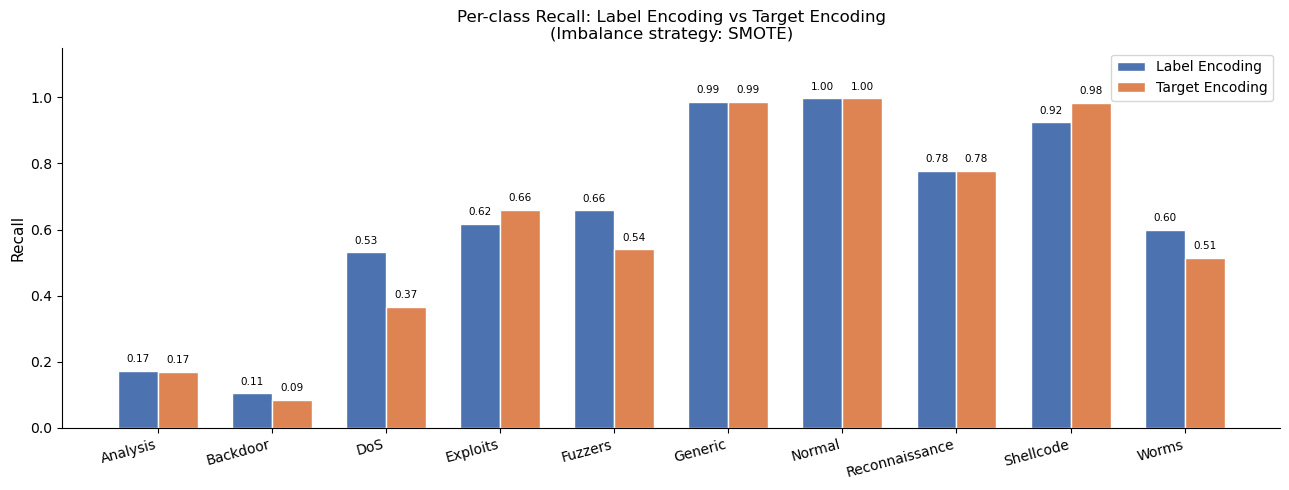

Saved: reports/ablation2_encoding_recall.png


In [8]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

FIGURE_DIR = PROJECT_ROOT / 'reports'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

classes_plot = sorted(y_test.unique())
x = np.arange(len(classes_plot))
width = 0.35

le_recalls = [report_le.get(c, {}).get('recall', 0.0) for c in classes_plot]
te_recalls = [report_te.get(c, {}).get('recall', 0.0) for c in classes_plot]

fig, ax = plt.subplots(figsize=(13, 5))
bars1 = ax.bar(x - width/2, le_recalls, width, label='Label Encoding',  color='#4C72B0', edgecolor='white')
bars2 = ax.bar(x + width/2, te_recalls, width, label='Target Encoding', color='#DD8452', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(classes_plot, fontsize=10, rotation=15, ha='right')
ax.set_ylabel('Recall', fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_title(
    f'Per-class Recall: Label Encoding vs Target Encoding\n'
    f'(Imbalance strategy: {BEST_IMBALANCE_STRATEGY})', fontsize=12
)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar in bars1:
    h = bar.get_height()
    if h > 0.02:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.02, f'{h:.2f}',
                ha='center', va='bottom', fontsize=7.5)
for bar in bars2:
    h = bar.get_height()
    if h > 0.02:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.02, f'{h:.2f}',
                ha='center', va='bottom', fontsize=7.5)

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'ablation2_encoding_recall.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: reports/ablation2_encoding_recall.png')

## Ablation 2 Conclusion

Record best encoding here after running.

**Fixed pipeline for downstream notebooks:**
- Class imbalance strategy: SMOTE (Ablation 1 best)
- Encoding strategy: [Ablation 2 best]

Pass these two decisions to:
- Notebook 05, 06 (Stream A — 서하)
- Notebook 07 (Stream B — 준원)

Figure saved to reports/:
- ablation2_encoding_recall.png — PPT 삽입용